# FASE 3 - ANALISAR DADOS + CAMADA GOLD

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

from config import MYSQL_CONFIG

engine = create_engine(
    f"mysql+mysqlconnector://"
    f"{MYSQL_CONFIG['user']}:"
    f"{MYSQL_CONFIG['password']}@"
    f"{MYSQL_CONFIG['host']}:"
    f"{MYSQL_CONFIG['port']}/"
    f"{MYSQL_CONFIG['database']}"
)

print("Conexão realizada!")

Conexão realizada!


1ª Pergunta de negócio:
Quais são os 5 órgãos com maior custo total em viagens?

In [2]:
sql = """
SELECT
    nome_orgao_solicitante,
    SUM(valor_total) AS custo_total
FROM silver_viagem
GROUP BY nome_orgao_solicitante
ORDER BY custo_total DESC
LIMIT 5;
"""

df_orgao_custo = pd.read_sql(
    sql,
    engine
)

df_orgao_custo.style.format(
    {
        "custo_total": "R$ {:,.2f}"
    }
)

,nome_orgao_solicitante,custo_total
0,Ministério da Justiça e Segurança Pública - Unidades com vínculo direto,"R$ 321,066,263.24"
1,Polícia Federal,"R$ 119,429,081.75"
2,Comando da Aeronáutica,"R$ 82,079,763.55"
3,Polícia Rodoviária Federal,"R$ 49,160,830.26"
4,Comando do Exército,"R$ 48,816,405.53"


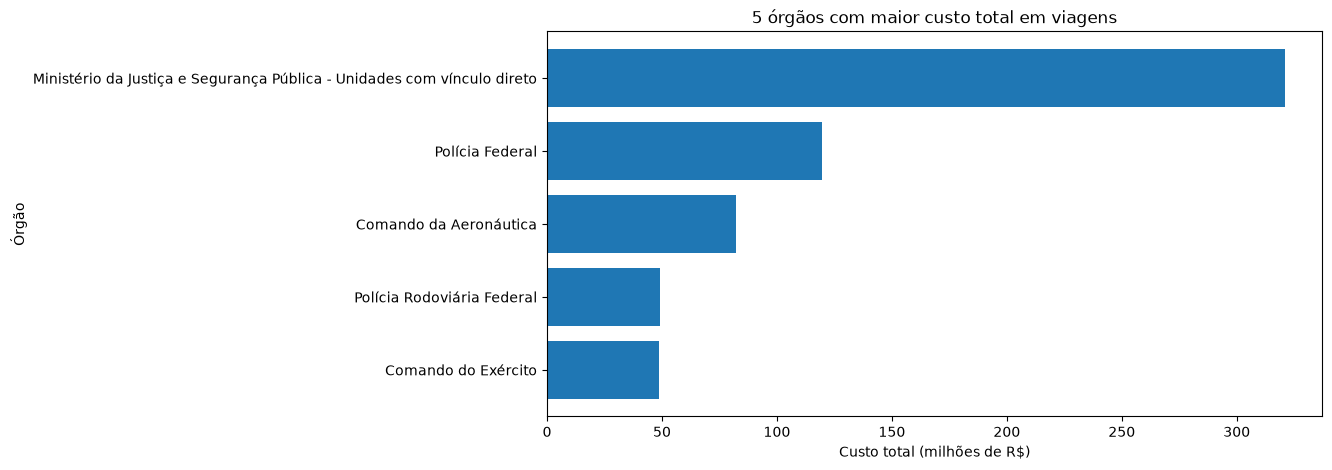

In [3]:
#Gráfico
df_orgao_custo["custo_milhoes"] = (
    df_orgao_custo["custo_total"] / 1_000_000
)

plt.figure(figsize=(10,5))

plt.barh(
    df_orgao_custo["nome_orgao_solicitante"],
    df_orgao_custo["custo_milhoes"]
)

plt.xlabel("Custo total (milhões de R$)")

plt.ylabel("Órgão")

plt.title("5 órgãos com maior custo total em viagens")

plt.gca().invert_yaxis()

plt.show()

2ª Pergunta de negócio:
Quais são os 3 destinos com maior custo médio por viagem?

In [4]:
sql = """
SELECT
    destinos,
    COUNT(*) AS quantidade_viagens,
    AVG(valor_total) AS custo_medio
FROM silver_viagem
GROUP BY destinos
ORDER BY custo_medio DESC
LIMIT 3;
"""

df_destinos = pd.read_sql(
    sql,
    engine
)

df_destinos["custo_medio_formatado"] = (
    df_destinos["custo_medio"]
    .map(lambda x: f"R$ {x:,.2f}")
)

df_destinos

,destinos,quantidade_viagens,custo_medio,custo_medio_formatado
0,"Abu Dabi/Emirados Árabes, Riad/Arábia Saudita,...",1,245852.80,"R$ 245,852.80"
1,"Brasília/DF, Rio Branco/AC, Cruzeiro do Sul/AC...",1,216729.36,"R$ 216,729.36"
2,"Brasília/DF, Rio de Janeiro/RJ, Angra dos Reis...",1,207220.14,"R$ 207,220.14"


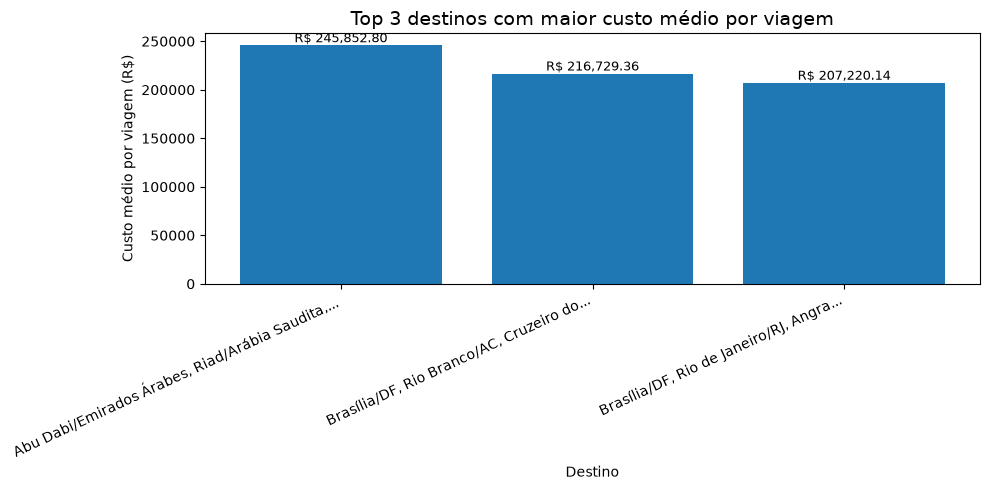

In [5]:
#Gráfico
df_destinos["destino_curto"] = (
    df_destinos["destinos"]
    .astype(str)
    .apply(
        lambda x: " ".join(x.split()[:5]) + "..."
    )
)

plt.figure(figsize=(10, 5))

barras = plt.bar(
    df_destinos["destino_curto"],
    df_destinos["custo_medio"]
)

plt.title(
    "Top 3 destinos com maior custo médio por viagem",
    fontsize=14
)

plt.xlabel("Destino")
plt.ylabel("Custo médio por viagem (R$)")

for barra, valor in zip(
    barras,
    df_destinos["custo_medio"]
):
    plt.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height(),
        f"R$ {valor:,.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

plt.show()

3ª Pergunta de negócio:
Qual foi a viagem de maior duração e qual seu custo total?

In [6]:
sql = """
SELECT
    identificador_processo_viagem,
    nome,
    nome_orgao_solicitante,
    data_inicio,
    data_fim,
    duracao_dias,
    valor_total
FROM silver_viagem
ORDER BY duracao_dias DESC
LIMIT 1;
"""

df_maior_viagem = pd.read_sql(
    sql,
    engine
)

df_maior_viagem

,identificador_processo_viagem,nome,nome_orgao_solicitante,data_inicio,data_fim,duracao_dias,valor_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,Instituto Nacional do Seguro Social,2025-01-13,2026-01-31,383,0.0


Considerando que se trata de mera informação única, deixa-se de apresentar gráfico.

4ª Pergunta de negócio:
Qual o tipo de pagamento com maior valor médio?

In [7]:
sql = """
SELECT
    tipo_pagamento,
    AVG(
        CAST(
            REPLACE(valor, ',', '.')
            AS DECIMAL(12,2)
        )
    ) AS valor_medio
FROM raw_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC;
"""

df_pagamento = pd.read_sql(
    sql,
    engine
)

df_pagamento["valor_medio_formatado"] = (
    df_pagamento["valor_medio"]
    .map(lambda x: f"R$ {x:,.2f}")
)

df_pagamento

,tipo_pagamento,valor_medio,valor_medio_formatado
0,DIÁRIAS,2078.280299,"R$ 2,078.28"
1,PASSAGEM,1878.344393,"R$ 1,878.34"
2,Serviço correlato: seguro,447.514653,R$ 447.51
3,RESTITUIÇÃO,245.702610,R$ 245.70


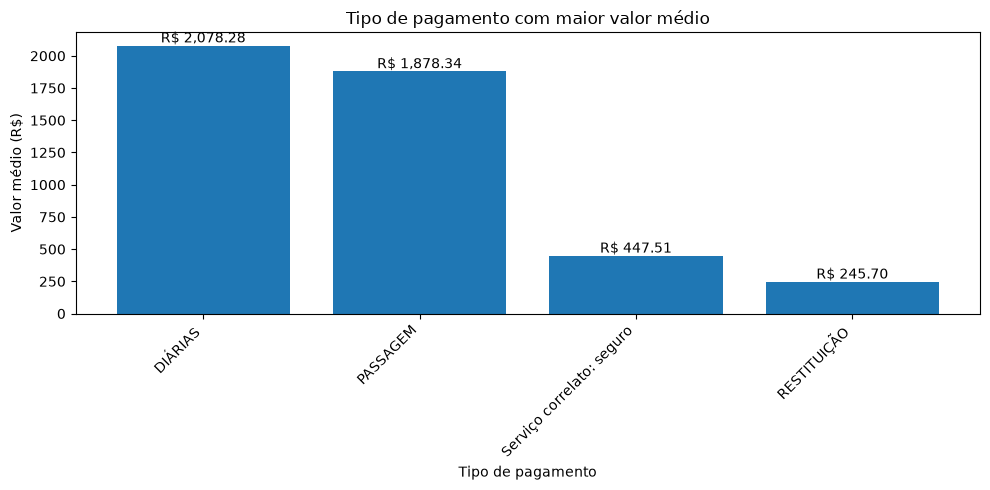

In [8]:
#Gráfico
plt.figure(figsize=(10,5))

plt.bar(
    df_pagamento["tipo_pagamento"],
    df_pagamento["valor_medio"]
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.title("Tipo de pagamento com maior valor médio")

plt.xlabel("Tipo de pagamento")

plt.ylabel("Valor médio (R$)")

for i, valor in enumerate(df_pagamento["valor_medio"]):
    plt.text(
        i,
        valor,
        f"R$ {valor:,.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()

5ª Pergunta de negócio:
Qual o meio de transporte mais usado nos trechos?

In [9]:
sql = """
SELECT
    meio_transporte,
    COUNT(*) AS quantidade
FROM raw_trecho
GROUP BY meio_transporte
ORDER BY quantidade DESC
LIMIT 10;
"""

df_transporte = pd.read_sql(
    sql,
    engine
)

df_transporte

,meio_transporte,quantidade
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


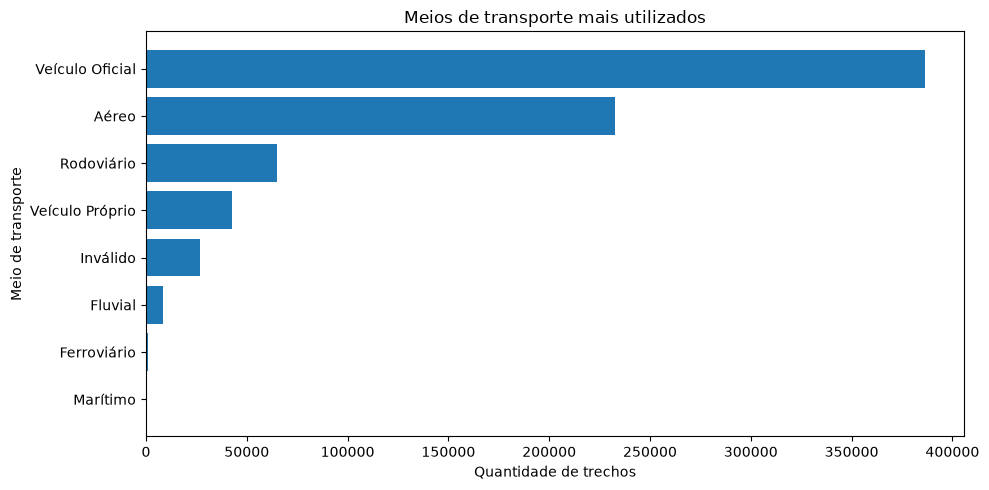

In [10]:
#Gráfico
plt.figure(figsize=(10,5))

plt.barh(
    df_transporte["meio_transporte"],
    df_transporte["quantidade"]
)

plt.xlabel("Quantidade de trechos")

plt.ylabel("Meio de transporte")

plt.title("Meios de transporte mais utilizados")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

6ª Pergunta de negócio:
Qual UF de destino aparece em mais trechos?

In [13]:
sql = """
SELECT
    destino_uf,
    COUNT(*) AS quantidade
FROM silver_trecho
GROUP BY destino_uf
ORDER BY quantidade DESC
LIMIT 10;
"""

df_uf = pd.read_sql(
    sql,
    engine
)

df_uf

,destino_uf,quantidade
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


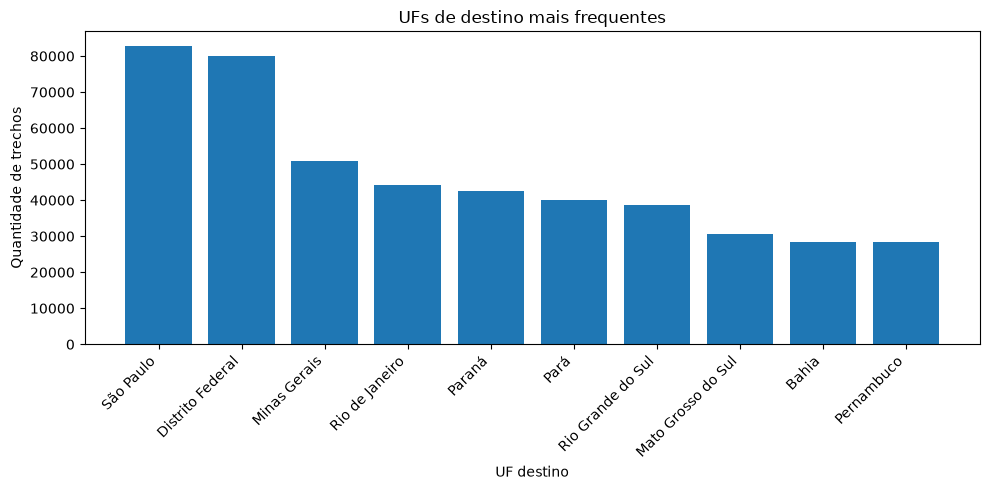

In [15]:
#Gráfico
plt.figure(figsize=(10,5))

plt.bar(
    df_uf["destino_uf"],
    df_uf["quantidade"]
)

plt.xlabel("UF destino")

plt.ylabel("Quantidade de trechos")

plt.title(
    "UFs de destino mais frequentes"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

7ª Pergunta de negócio:
Qual órgão pagou mais no total?

In [16]:
sql = """
SELECT
    nome_orgao_pagador,
    SUM(
        CAST(
            REPLACE(valor, ',', '.')
            AS DECIMAL(12,2)
        )
    ) AS total_pago
FROM raw_pagamento
GROUP BY nome_orgao_pagador
ORDER BY total_pago DESC
LIMIT 10;
"""

df_orgao_pagador = pd.read_sql(
    sql,
    engine
)

df_orgao_pagador.style.format(
    {
        "total_pago": "R$ {:,.2f}"
    }
)

,nome_orgao_pagador,total_pago
0,Fundo Nacional de Segurança Pública,"R$ 278,481,047.89"
1,Sigiloso,"R$ 200,484,801.68"
2,Comando da Aeronáutica,"R$ 81,769,144.77"
3,Instituto Nacional do Seguro Social,"R$ 37,427,601.45"
4,Comando do Exército,"R$ 36,872,643.95"
5,Ministério da Gestão e da Inovação em Serviços Públicos - Unidades com vínculo direto,"R$ 35,541,760.71"
6,Instituto Brasileiro do Meio Ambiente e dos Recursos Naturais Renováveis,"R$ 31,589,853.15"
7,Ministério das Relações Exteriores - Unidades com vínculo direto,"R$ 25,605,376.38"
8,Receita Federal do Brasil,"R$ 23,811,027.00"
9,Ministério da Agricultura e Pecuária - Unidades com vínculo direto,"R$ 22,899,880.25"


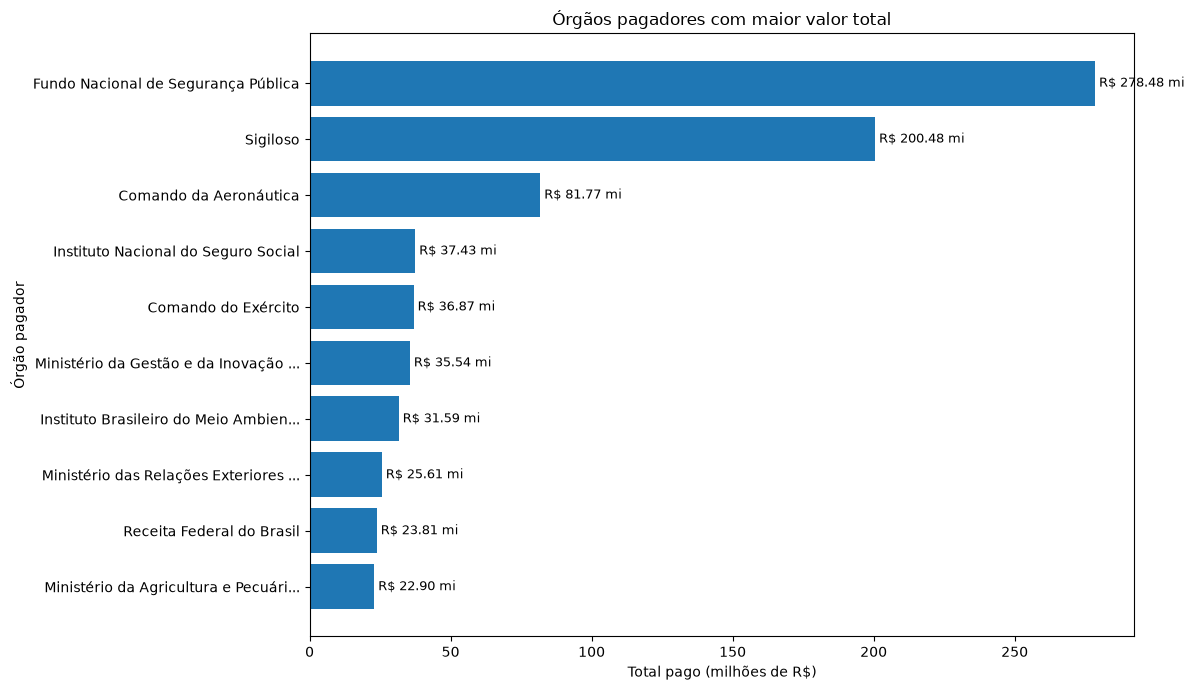

In [17]:
#Gráfico
df_orgao_pagador["orgao_curto"] = (
    df_orgao_pagador["nome_orgao_pagador"]
    .astype(str)
    .apply(
        lambda x: x[:35] + "..." if len(x) > 35 else x
    )
)

df_orgao_pagador["total_milhoes"] = (
    df_orgao_pagador["total_pago"] / 1_000_000
)

plt.figure(figsize=(12,7))

barras = plt.barh(
    df_orgao_pagador["orgao_curto"],
    df_orgao_pagador["total_milhoes"]
)

plt.xlabel("Total pago (milhões de R$)")

plt.ylabel("Órgão pagador")

plt.title("Órgãos pagadores com maior valor total")

plt.gca().invert_yaxis()

for barra, valor in zip(
    barras,
    df_orgao_pagador["total_milhoes"]
):
    plt.text(
        barra.get_width(),
        barra.get_y() + barra.get_height()/2,
        f" R$ {valor:,.2f} mi",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()

# CAMADA GOLD
A camada Gold foi criada no MySQL a partir da integração das camadas Raw e Silver.

Foi criada uma tabela agregada utilizando JOIN e GROUP BY, relacionando:
- silver_viagem: dados tratados das viagens;
- raw_pagamento: informações financeiras dos pagamentos;
- raw_trecho: informações dos trechos realizados.

A tabela criada foi:
- gold_indicadores_viagem

Também foi criada uma VIEW:
- vw_gold_indicadores_viagem

A camada Gold será utilizada para responder perguntas de negócio a seguir.

1ª Pergunda camada gold:
Quais órgãos tiveram maior gasto considerando viagens e pagamentos?

In [18]:
sql = """
SELECT
    nome_orgao_solicitante,
    ROUND(
        custo_total_viagens + total_pago,
        2
    ) AS gasto_total
FROM gold_indicadores_viagem
ORDER BY gasto_total DESC
LIMIT 10;
"""

df_gasto_orgao = pd.read_sql(
    sql,
    engine
)

df_gasto_orgao["gasto_total_formatado"] = (
    df_gasto_orgao["gasto_total"]
    .map(
        lambda x: f"R$ {x:,.2f}"
    )
)

df_gasto_orgao

,nome_orgao_solicitante,gasto_total,gasto_total_formatado
0,Ministério da Justiça e Segurança Pública - Un...,1.161454e+11,"R$ 116,145,449,909.47"
1,Polícia Federal,7.586528e+08,"R$ 758,652,838.42"
2,Comando da Aeronáutica,6.834999e+08,"R$ 683,499,878.10"
3,Instituto Brasileiro do Meio Ambiente e dos Re...,6.094396e+08,"R$ 609,439,554.73"
4,Instituto Nacional do Seguro Social,5.977549e+08,"R$ 597,754,852.53"
5,Comando do Exército,5.542584e+08,"R$ 554,258,434.83"
6,Fundação Nacional dos Povos Indígenas,3.555523e+08,"R$ 355,552,285.71"
7,Sem informação,3.507365e+08,"R$ 350,736,547.95"
8,Ministério da Fazenda - Unidades com vínculo d...,3.190274e+08,"R$ 319,027,360.69"
9,Ministério das Relações Exteriores - Unidades ...,2.466797e+08,"R$ 246,679,679.29"


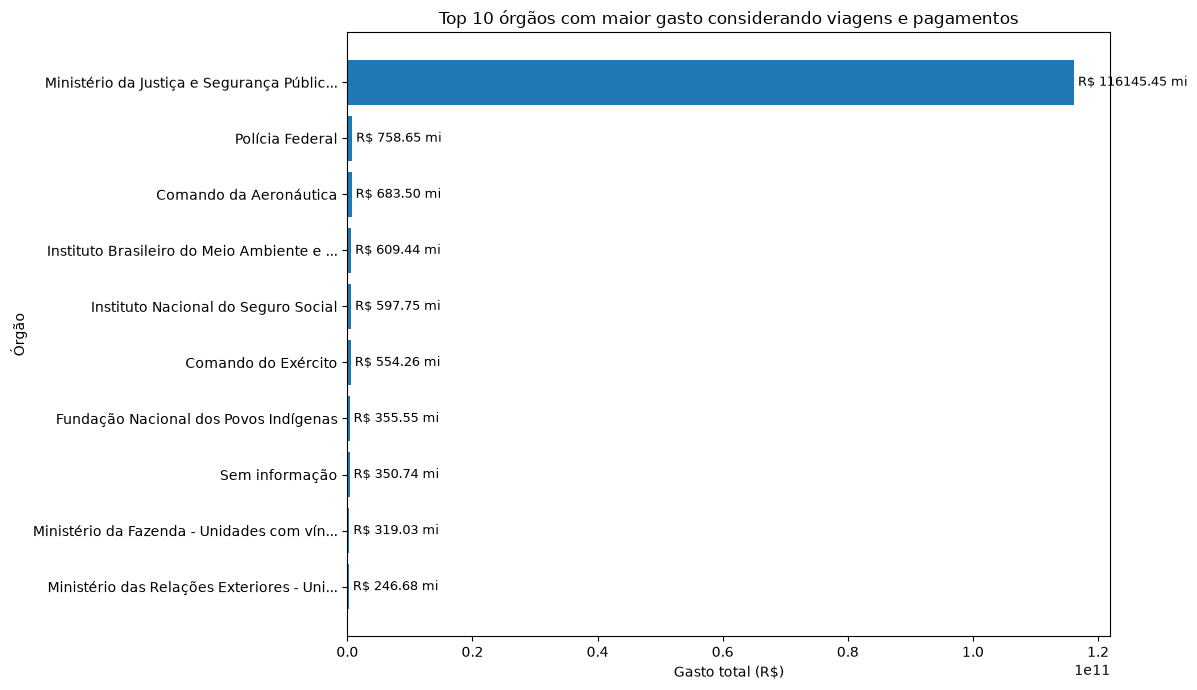

In [19]:
#Gráfico
plt.figure(figsize=(12,7))

df_gasto_orgao["orgao_curto"] = (
    df_gasto_orgao["nome_orgao_solicitante"]
    .astype(str)
    .apply(
        lambda x: x[:40] + "..." if len(x) > 40 else x
    )
)

barras = plt.barh(
    df_gasto_orgao["orgao_curto"],
    df_gasto_orgao["gasto_total"]
)

plt.xlabel("Gasto total (R$)")

plt.ylabel("Órgão")

plt.title("Top 10 órgãos com maior gasto considerando viagens e pagamentos")

plt.gca().invert_yaxis()

for barra, valor in zip(
    barras,
    df_gasto_orgao["gasto_total"]
):
    plt.text(
        barra.get_width(),
        barra.get_y() + barra.get_height()/2,
        f" R$ {valor/1_000_000:.2f} mi",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()

2ª Pergunda camada gold:
Quais órgãos possuem maior quantidade de trechos?

In [20]:
sql = """
SELECT
    nome_orgao_solicitante,
    quantidade_trechos
FROM gold_indicadores_viagem
ORDER BY quantidade_trechos DESC
LIMIT 10;
"""

df_trechos_orgao = pd.read_sql(
    sql,
    engine
)

df_trechos_orgao["orgao_curto"] = (
    df_trechos_orgao["nome_orgao_solicitante"]
    .astype(str)
    .apply(
        lambda x: x[:40] + "..." if len(x) > 40 else x
    )
)

df_trechos_orgao[
    [
        "orgao_curto",
        "quantidade_trechos"
    ]
]

,orgao_curto,quantidade_trechos
0,Ministério da Justiça e Segurança Públic...,1053737
1,Comando da Aeronáutica,128255
2,Comando do Exército,103809
3,Instituto Brasileiro do Meio Ambiente e ...,60693
4,Sem informação,59769
5,Instituto Nacional do Seguro Social,51304
6,Fundação Instituto Brasileiro de Geograf...,50693
7,Ministério da Fazenda - Unidades com vín...,50410
8,Instituto Chico Mendes de Conservação da...,43242
9,Ministério da Saúde - Unidades com víncu...,26252


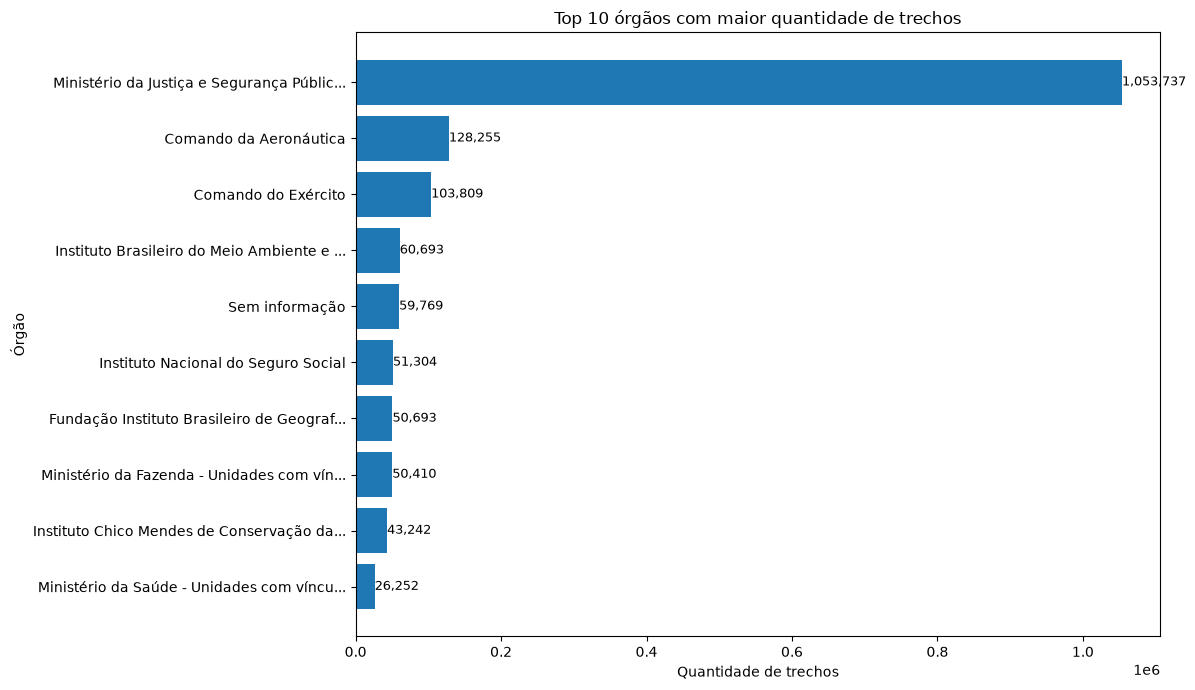

In [21]:
#Gráfico
plt.figure(figsize=(12,7))

barras = plt.barh(
    df_trechos_orgao["orgao_curto"],
    df_trechos_orgao["quantidade_trechos"]
)

plt.xlabel("Quantidade de trechos")

plt.ylabel("Órgão")

plt.title("Top 10 órgãos com maior quantidade de trechos")

plt.gca().invert_yaxis()

for barra, valor in zip(
    barras,
    df_trechos_orgao["quantidade_trechos"]
):
    plt.text(
        barra.get_width(),
        barra.get_y() + barra.get_height()/2,
        f"{valor:,}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()

3ª Pergunda camada gold:
Quais órgãos possuem maior duração média das viagens?

In [27]:
sql = """
SELECT
    nome_orgao_solicitante,
    ROUND(duracao_media, 2) AS duracao_media_dias
FROM gold_indicadores_viagem
ORDER BY duracao_media DESC
LIMIT 10;
"""

df_duracao_orgao = pd.read_sql(
    sql,
    engine
)

# Criar nome reduzido para visualização do gráfico
df_duracao_orgao["orgao_curto"] = (
    df_duracao_orgao["nome_orgao_solicitante"]
    .astype(str)
    .apply(
        lambda x: x[:40] + "..." if len(x) > 40 else x
    )
)

df_duracao_orgao

,nome_orgao_solicitante,duracao_media_dias,orgao_curto
0,Ministério da Justiça e Segurança Pública - Un...,310.22,Ministério da Justiça e Segurança Públic...
1,Fundação Nacional dos Povos Indígenas,29.49,Fundação Nacional dos Povos Indígenas
2,Polícia Federal,28.54,Polícia Federal
3,Instituto Nacional do Seguro Social,26.27,Instituto Nacional do Seguro Social
4,Universidade Federal Fluminense,20.90,Universidade Federal Fluminense
5,Instituto Brasileiro do Meio Ambiente e dos Re...,17.35,Instituto Brasileiro do Meio Ambiente e ...
6,Polícia Rodoviária Federal,11.89,Polícia Rodoviária Federal
7,Companhia Nacional de Abastecimento,11.22,Companhia Nacional de Abastecimento
8,Ministério das Relações Exteriores - Unidades ...,10.91,Ministério das Relações Exteriores - Uni...
9,Ministério da Previdência Social - Unidades co...,9.93,Ministério da Previdência Social - Unida...


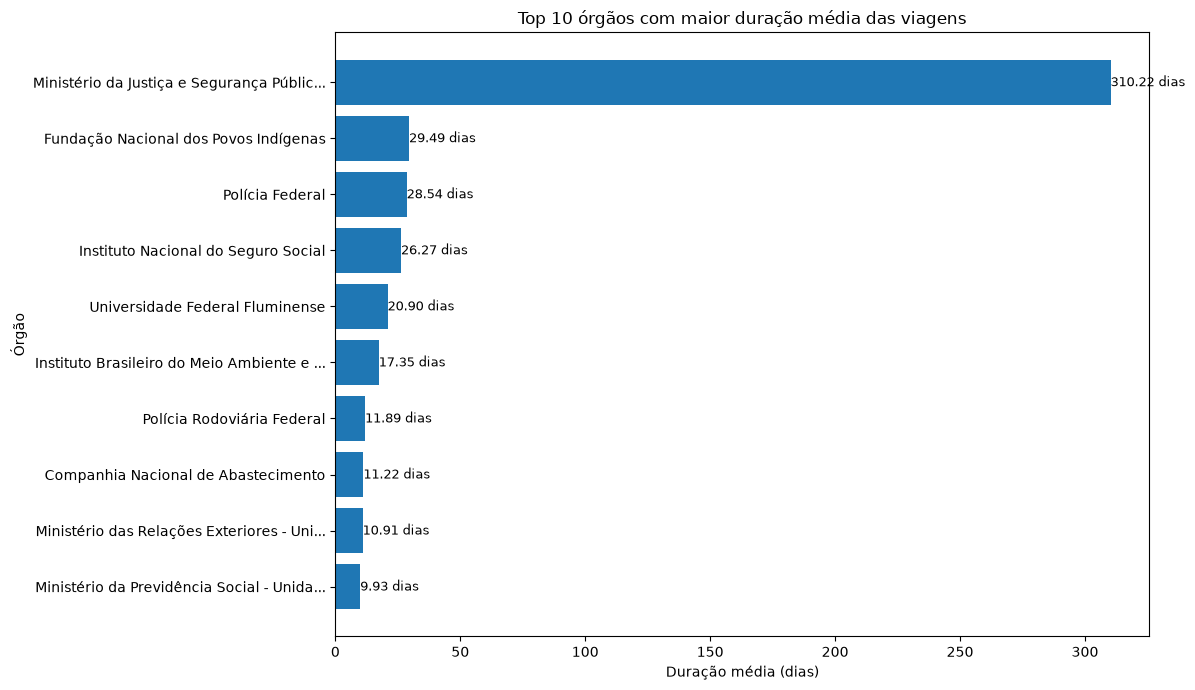

In [28]:
#Gráfico
plt.figure(figsize=(12,7))

barras = plt.barh(
    df_duracao_orgao["orgao_curto"],
    df_duracao_orgao["duracao_media_dias"]
)

plt.xlabel("Duração média (dias)")

plt.ylabel("Órgão")

plt.title("Top 10 órgãos com maior duração média das viagens")

plt.gca().invert_yaxis()

for barra, valor in zip(
    barras,
    df_duracao_orgao["duracao_media_dias"]
):
    plt.text(
        barra.get_width(),
        barra.get_y() + barra.get_height()/2,
        f"{valor:.2f} dias",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()